# Backtest LGBM Dual Implied Signed

Loads a saved LightGBM dual-head model pack (`lgbm_dual`), regenerates `LGBM_dual_implied_signed = long_pred - short_pred`, and runs a directional backtest on a validation OHLCV dataset.

Run all cells top-to-bottom.

In [117]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from Learn.features import _add_features_US500_v2

warnings.filterwarnings('ignore')

# Define FEATURES in __main__ so pickle.load() can resolve the reference
# when deserializing the model pack. This must match the training notebook's
# FEATURES function exactly (single-pass with selected_features).
# The pack stores its own feature_function which we use for inference.
def FEATURES(df, include_mtf=True, regime_params=None):
    # Single-pass feature engineering to avoid _x/_y suffixed duplicate columns.
    # The training notebook now generates features from fresh raw data,
    # so the pack's feature_function is a single-pass call.
    df = _add_features_US500_v2(df, include_mtf=include_mtf, regime_params=regime_params)
    return df


In [118]:
# --- Configuration ---
MODEL_PACK_PATH = r'ModelPacks/US500_M1_520weeks_LightGBM_20260704_spearman_prod_TP4.0_SL2.5_model.pkl'
DS_NAME = r'../data/US500_M1_520weeks.csv'
EVAL_START = None
EVAL_END = None
N_ROWS = 10_000
WARMUP_BARS = 7_000

TP_MULT = None  # Use model pack values
SL_MULT = None  # Use model pack values

# Production-parity execution settings
# NOTE: pred_long values are typically ~0.3-0.5, so threshold 0.95 is too high.
# The threshold sweep will find the optimal value, but start with a lower default.
TRADE_THRESHOLD   = 0.80
QUALITY_THRESHOLD = 0.60
PATIENCE = 1
ENTRY_BUFFER = 0.00001
MAX_POS_SIZE = None  # If not None, filters out trades with position_size > MAX_POS_SIZE
TRADING_HOURS = None  # If the pack provides a restricted session, we will use it.

# Directional backtest settings
LOOKAHEAD_BARS = 30

# --- For EURUSD, adjust as needed ---
TOP_PCTS = (0.01, 0.05, 0.10)
PIP_SIZE = 0.0001
RISK = 10.0
COMMISSION_USD = 0.00

# Analysis-only gates. Leave off for the production emulation path.
GATE_BREAKOUT = True
GATE_REGIME = False
GATE_DONCHIAN = False

assert os.path.exists(MODEL_PACK_PATH), f'Model pack not found: {MODEL_PACK_PATH}'
assert os.path.exists(DS_NAME), f'Dataset not found: {DS_NAME}'
print('Model pack:', MODEL_PACK_PATH)
print('Dataset:', DS_NAME)


Model pack: ModelPacks/US500_M1_520weeks_LightGBM_20260704_spearman_prod_TP4.0_SL2.5_model.pkl
Dataset: ../data/US500_M1_520weeks.csv


## Load Model Pack
Loads the pickled pack and extracts model, preprocessing, and metadata.

In [119]:
with open(MODEL_PACK_PATH, 'rb') as f:
    pack = pickle.load(f)

model = pack.get('model')
primary_model = pack.get('primary_model', model)
aux_models = pack.get('aux_models', {})
model_info = pack.get('model_info', {})
model_params = pack.get('model_params', {})
features = pack.get('features', [])
selected_features = pack.get('selected_features', None)
feature_fn = pack['feature_function']

# Reconstruct a reliable feature function using the imported _add_features_US500_v2.
# The pickled feature_function may break across sessions due to __main__ closure issues.
if feature_fn is None or not callable(feature_fn):
    def feature_fn(df, include_mtf=True, regime_params=None):
        return _add_features_US500_v2(df, include_mtf=include_mtf, regime_params=regime_params, selected_features=selected_features)
elif feature_fn.__code__.co_name == '<lambda>':
    # If it's a lambda (e.g., from FEATURES redefinition), use imported version instead
    _orig_fn = feature_fn
    def feature_fn(df, include_mtf=True, regime_params=None):
        return _add_features_US500_v2(df, include_mtf=include_mtf, regime_params=regime_params, selected_features=selected_features)

preprocess_fn = pack['preprocess_function']
preprocess_args = {**pack['preprocess_args']}
saved_scaler = pack.get('scaler')
regime_params = pack.get('regime_params', None)
outcome_params = pack.get('outcome_params', None) or {}

TRADING_HOURS = pack.get('trading_hours', TRADING_HOURS)
# TRADE_THRESHOLD = float(pack.get('trade_threshold', TRADE_THRESHOLD))
# QUALITY_THRESHOLD = float(pack.get('quality_threshold', QUALITY_THRESHOLD))
PATIENCE = int(pack.get('patience', PATIENCE))

if TP_MULT is None:
    TP_MULT = outcome_params.get('tp_mult', None)
if SL_MULT is None:
    SL_MULT = outcome_params.get('sl_mult', None)

print('Model type:', model_info.get('model_type', type(model).__name__))
print('Trained date:', model_info.get('date_trained', 'n/a'))
print('Feature count in pack:', len(features))
print('Preprocess target columns:', preprocess_args.get('target_col', None))
print('Aux models:', sorted(aux_models.keys()) if isinstance(aux_models, dict) else type(aux_models).__name__)
print('Trading hours:', TRADING_HOURS)
print('Trade threshold:', TRADE_THRESHOLD)
print('Quality threshold:', QUALITY_THRESHOLD)
print('Patience:', PATIENCE)
print('Regime params (from pack):', regime_params)
type(model)


Model type: LightGBMRegressionPack
Trained date: 20260704
Feature count in pack: 65
Preprocess target columns: ['long_quality', 'short_quality', 'signed_quality', 'tradeability_score', 'buy_win', 'sell_win', 'signed_win']
Aux models: ['long_quality', 'short_quality']
Trading hours: None
Trade threshold: 0.8
Quality threshold: 0.6
Patience: 1
Regime params (from pack): {'ma_period': 90, 'slope_smoothness': 50, 'regime_min_duration': 0, 'atr_window': 60, 'atr_lookback': 720, 'atr_percentile': 0.0, 'slope_threshold': 0}


lightgbm.sklearn.LGBMRegressor

In [120]:
# Use the pack's stored regime_params (matches training).
# Do NOT override with different values - this causes feature distribution shifts.
print('Using regime_params from model pack:', regime_params)

Using regime_params from model pack: {'ma_period': 90, 'slope_smoothness': 50, 'regime_min_duration': 0, 'atr_window': 60, 'atr_lookback': 720, 'atr_percentile': 0.0, 'slope_threshold': 0}


## Load and Prepare Evaluation Data
Applies the same feature and preprocessing pipeline saved in the pack.

In [121]:
df_raw = pd.read_csv(DS_NAME)
df_raw = df_raw.sort_values('Time').reset_index(drop=True)
df_raw['Time'] = pd.to_datetime(df_raw['Time'])


if EVAL_START is not None:
    df_raw = df_raw[df_raw['Time'] >= pd.to_datetime(EVAL_START)]
if EVAL_END is not None:
    df_raw = df_raw[df_raw['Time'] <= pd.to_datetime(EVAL_END)]
if N_ROWS is not None:
    df_raw = df_raw.tail(N_ROWS + WARMUP_BARS)

df_raw = df_raw.reset_index(drop=True)
print(f'Eval range: {df_raw.Time.iloc[0]} -> {df_raw.Time.iloc[-1]}')
print(f'Raw rows: {len(df_raw):,}')

# Use the pack's feature_function (single-pass, matching training).
# IMPORTANT: Do NOT call feature_fn twice - the training notebook now uses
# a single-pass approach to avoid _x/_y suffixed duplicate columns.
df_feat = feature_fn(df_raw.copy(), include_mtf=True, regime_params=regime_params)
df_feat = df_feat.dropna().reset_index(drop=True)

# Keep only latest evaluation region after warmup
if WARMUP_BARS > 0:
    df_feat = df_feat.tail(N_ROWS).reset_index(drop=True)

# Compatibility patch for older packs: some packs include ATR in their feature schema
# while current feature_fn no longer returns it.
if ('atr' in features) and ('atr' not in df_feat.columns):
    from talib import ATR
    df_feat['atr'] = ATR(df_feat['High'].values.astype(float), df_feat['Low'].values.astype(float), df_feat['Close'].values.astype(float), timeperiod=14)

# Subset to only the features the pack was trained on.
# This is critical when the feature function generates more columns than the pack expects
# (e.g. when _add_features_US500_v2 is used without selected_features filtering).
pack_feature_set = set(features)
extra_cols = [c for c in df_feat.columns if c not in pack_feature_set and c not in ['Time', 'Open', 'High', 'Low', 'Close', 'Volume']]
if extra_cols:
    print(f'Dropping {len(extra_cols)} extra columns not in pack feature set')
    df_feat = df_feat.drop(columns=extra_cols)

# Reorder features to match the saved pack feature list exactly.
ordered_cols = [c for c in ['Time','Open','High','Low','Close','Volume'] + features if c in df_feat.columns]
df_feat = df_feat[ordered_cols]

# Validate that all pack features are present before preprocess/scaler transform
missing_pack_features = [c for c in features if c not in df_feat.columns]
if missing_pack_features:
    raise ValueError(
        f'Missing packed features in current engineered frame: {missing_pack_features}'
    )

print('Feature matrix rows after feature engineering:', len(df_feat))
print('Feature columns in pack:', len(features))


prep_args_eval = {**preprocess_args}
prep_args_eval['target_col'] = None
prep_args_eval['outcomes_col'] = None

X_eval, _, _, _, _, df_eval_proc = preprocess_fn(
    df_feat,
    scaler=saved_scaler,
    return_df=True,
    **prep_args_eval,
)

X_eval = np.ascontiguousarray(X_eval)
time_eval = pd.to_datetime(df_eval_proc['Time']).reset_index(drop=True)

print('Prepared matrix:', X_eval.shape)
print('Processed timeline rows:', len(time_eval))

Eval range: 2026-06-03 09:19:00+00:00 -> 2026-06-19 16:59:00+00:00
Raw rows: 17,000
Dropping 133 extra columns not in pack feature set
Feature matrix rows after feature engineering: 10000
Feature columns in pack: 65
Prepared matrix: (9986, 65)
Processed timeline rows: 9986


## Regenerate LGBM Dual Implied Signed
Generates `long_pred`, `short_pred`, and `lgbm_dual_implied_signed`.

In [122]:
def _predict_pack_outputs(X):
    # Preferred path for the refactored pack: long/short aux models plus a signed primary model.
    if isinstance(aux_models, dict) and {'long_quality', 'short_quality'}.issubset(aux_models.keys()):
        pred_long = np.asarray(aux_models['long_quality'].predict(X)).reshape(-1)
        pred_short = np.asarray(aux_models['short_quality'].predict(X)).reshape(-1)
        pred_signed_direct = np.asarray(primary_model.predict(X)).reshape(-1)
        pred_signed_implied = pred_long - pred_short
        return pred_long, pred_short, pred_signed_implied, pred_signed_direct

    # Legacy path: a single dual-output model returns (N, 2)
    pred = np.asarray(model.predict(X))
    if pred.ndim == 2 and pred.shape[1] == 2:
        pred_long = pred[:, 0]
        pred_short = pred[:, 1]
        pred_signed_implied = pred_long - pred_short
        return pred_long, pred_short, pred_signed_implied, pred_signed_implied

    # Fallback: signed-only model. Build a directional proxy so the rest of the notebook still works.
    pred_signed = pred.reshape(-1)
    pred_long = np.maximum(pred_signed, 0.0)
    pred_short = np.maximum(-pred_signed, 0.0)
    return pred_long, pred_short, pred_signed, pred_signed


pred_long, pred_short, lgbm_dual_implied_signed, pred_signed_direct = _predict_pack_outputs(X_eval)

pred_df = pd.DataFrame({
    'Time': time_eval,
    'pred_long': pred_long,
    'pred_short': pred_short,
    'pred_signed': lgbm_dual_implied_signed,
    'pred_signed_direct': pred_signed_direct,
})

if TRADING_HOURS is not None:
    t_start = pd.to_datetime(TRADING_HOURS[0]).time()
    t_end = pd.to_datetime(TRADING_HOURS[1]).time()
    in_session = pred_df['Time'].dt.time.between(t_start, t_end, inclusive='left')
    pred_df = pred_df.loc[in_session].reset_index(drop=True)

# Quick diagnostic: check prediction distributions
print('Prediction distribution summary:')
print(f'  pred_long:  mean={pred_long.mean():.4f}, median={np.median(pred_long):.4f}, max={pred_long.max():.4f}')
print(f'  pred_short: mean={pred_short.mean():.4f}, median={np.median(pred_short):.4f}, max={pred_short.max():.4f}')
print(f'  % short > long: {np.mean(pred_short > pred_long)*100:.1f}%')
print(f'  % long > short: {np.mean(pred_long > pred_short)*100:.1f}%')
print(f'  pred_signed_direct: mean={pred_signed_direct.mean():.4f}, % positive={np.mean(pred_signed_direct > 0)*100:.1f}%')

pred_df.head()


Prediction distribution summary:
  pred_long:  mean=0.5412, median=0.5234, max=1.2983
  pred_short: mean=0.5468, median=0.5324, max=1.3534
  % short > long: 49.3%
  % long > short: 50.7%
  pred_signed_direct: mean=-0.0093, % positive=50.3%


,Time,pred_long,pred_short,pred_signed,pred_signed_direct
0,2026-06-10 11:22:00+00:00,0.374710,0.382120,-0.007410,-0.049723
1,2026-06-10 11:23:00+00:00,0.477442,0.481348,-0.003906,0.003133
2,2026-06-10 11:24:00+00:00,0.181404,0.530882,-0.349478,-0.411819
3,2026-06-10 11:25:00+00:00,0.162209,0.404180,-0.241971,-0.237761
4,2026-06-10 11:26:00+00:00,0.488155,0.349554,0.138601,0.174592


## Generate Trade Entries

In [123]:
def prediction_to_signal(row, trade_threshold=TRADE_THRESHOLD, quality_threshold=QUALITY_THRESHOLD, trading_hours=TRADING_HOURS):
    # Convert raw model outputs into a production-style trade signal.
    #  1 -> buy stop order
    # -1 -> sell stop order
    #  0 -> no trade
    if trading_hours is not None:
        t_start = pd.to_datetime(trading_hours[0]).time()
        t_end = pd.to_datetime(trading_hours[1]).time()
        in_restricted_hours = t_start <= row['Time'].time() <= t_end
    else:
        in_restricted_hours = False

    quality = abs(row['pred_signed'])
    buy_ready = (row['pred_long'] >= trade_threshold) and (quality >= quality_threshold)
    sell_ready = (row['pred_short'] >= trade_threshold) and (quality >= quality_threshold)

    if in_restricted_hours:
        signal = 0
        reason = 'restricted_hours'
    elif buy_ready:
        signal = 1
        reason = 'buy_thresholds_met'
    elif sell_ready:
        signal = -1
        reason = 'sell_thresholds_met'
    else:
        signal = 0
        reason = 'below_threshold'

    return pd.Series({
        'quality': quality,
        'in_restricted_hours': in_restricted_hours,
        'buy_ready': buy_ready,
        'sell_ready': sell_ready,
        'raw_signal': signal,
        'signal_reason': reason,
    })


df = df_raw.merge(pred_df, on='Time', how='inner').sort_values('Time').reset_index(drop=True)
signal_cols = df.apply(
    prediction_to_signal,
    axis=1,
    trade_threshold=TRADE_THRESHOLD,
    quality_threshold=QUALITY_THRESHOLD,
    trading_hours=TRADING_HOURS,
)
df = pd.concat([df, signal_cols], axis=1)
df['signal'] = df['raw_signal'].astype(int)
df_gated = df.copy()

print(f'Raw signal counts: {df_gated["raw_signal"].value_counts().to_dict()}')
print(f'In restricted hours: {int(df_gated["in_restricted_hours"].sum()):,} rows')
print(df_gated[['Time', 'pred_long', 'pred_short', 'pred_signed', 'quality', 'raw_signal', 'signal_reason']].head())


Raw signal counts: {0: 9755, -1: 159, 1: 72}
In restricted hours: 0 rows
                       Time  pred_long  pred_short  pred_signed   quality  \
0 2026-06-10 11:22:00+00:00   0.374710    0.382120    -0.007410  0.007410   
1 2026-06-10 11:23:00+00:00   0.477442    0.481348    -0.003906  0.003906   
2 2026-06-10 11:24:00+00:00   0.181404    0.530882    -0.349478  0.349478   
3 2026-06-10 11:25:00+00:00   0.162209    0.404180    -0.241971  0.241971   
4 2026-06-10 11:26:00+00:00   0.488155    0.349554     0.138601  0.138601   

   raw_signal    signal_reason  
0           0  below_threshold  
1           0  below_threshold  
2           0  below_threshold  
3           0  below_threshold  
4           0  below_threshold  


In [124]:
# The live engine does not apply the old regime / breakout / Donchian gates.
# We keep the plotting dataframe separate, but the production-emulation signal
# stream is the raw strategy signal stream from cell 13.
df_gated = df.copy()
raw_counts = df_gated['raw_signal'].value_counts().rename({-1: 'SELL', 0: 'HOLD', 1: 'BUY'})
gate_counts = df_gated['signal'].value_counts().rename({-1: 'SELL', 0: 'HOLD', 1: 'BUY'})
summary = pd.DataFrame({'Raw': raw_counts, 'Gated': gate_counts}).fillna(0).astype(int)
summary['Removed'] = summary['Raw'] - summary['Gated']
print(f"\n{summary.to_string()}")



       Raw  Gated  Removed
HOLD  9755   9755        0
SELL   159    159        0
BUY     72     72        0


In [125]:
from talib import EMA as talib_EMA
from Learn.labels import super_smoother
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ── Build chart dataframe ─────────────────────────────────────────────────────
df_chart = df[['Time', 'Open', 'High', 'Low', 'Close', 'Volume']].copy().tail(10_000).reset_index(drop=True)
sig_cols = ['Time', 'signal', 'pred_long', 'pred_short', 'pred_signed']
df_chart = df_chart.merge(df_gated[sig_cols], on='Time', how='left')
df_chart['signal'] = df_chart['signal'].fillna(0).astype(int)
# df_chart['regime'] = df_chart['regime'].fillna(0)

df_chart['z_score'] = (df_chart['Close'] - df_chart['Close'].rolling(100).mean()) / df_chart['Close'].rolling(100).std()
df_chart['z_score_binary'] = (df_chart['z_score'] > 0).astype(int)

# ── Compute regime EMA and slope (same as causal_market_regime internals) ──────
ma_period        = regime_params.get('ma_period', 21) if regime_params else 21
slope_smoothness = regime_params.get('slope_smoothness', 1) if regime_params else 1

ma_arr = talib_EMA(df_chart['Close'].values.astype(float), timeperiod=ma_period)
ma_s   = pd.Series(ma_arr, index=df_chart.index)
slope  = ma_s.diff() / ma_s
df_chart['regime_ma'] = ma_s
df_chart['slope_sm']  = super_smoother(slope, period=max(slope_smoothness, 2))

buy_bars  = df_chart[df_chart['signal'] ==  1]
sell_bars = df_chart[df_chart['signal'] == -1]

atr_series = df_chart['High'].rolling(14).mean() - df_chart['Low'].rolling(14).mean()
offset     = float(atr_series.mean()) * 0.5

vol_colors = np.where(df_chart['Close'] >= df_chart['Open'], '#26a69a', '#ef5350')

fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    row_heights=[0.65, 0.15, 0.20], vertical_spacing=0.02)

# ── Row 1: Candlesticks ───────────────────────────────────────────────────────
fig.add_trace(go.Candlestick(
    x=df_chart['Time'], open=df_chart['Open'], high=df_chart['High'],
    low=df_chart['Low'], close=df_chart['Close'], name='OHLCV',
    increasing_line_color='#26a69a', decreasing_line_color='#ef5350',
    increasing_fillcolor='#26a69a', decreasing_fillcolor='#ef5350',
    line=dict(width=1), hoverinfo='skip'), row=1, col=1)

# ── Row 1: BUY / SELL signal markers ─────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=buy_bars['Time'], y=buy_bars['Low'] - offset, mode='markers',
    marker=dict(symbol='triangle-up', size=9, color='#00e676',
                line=dict(color='darkgreen', width=0.8)),
    name='BUY signal', hoverinfo='skip'), row=1, col=1)

fig.add_trace(go.Scatter(
    x=sell_bars['Time'], y=sell_bars['High'] + offset, mode='markers',
    marker=dict(symbol='triangle-down', size=9, color='#ff1744',
                line=dict(color='darkred', width=0.8)),
    name='SELL signal', hoverinfo='skip'), row=1, col=1)

# ── Row 2: Volume ─────────────────────────────────────────────────────────────
fig.add_trace(go.Bar(x=df_chart['Time'], y=df_chart['Volume'],
    marker_color=vol_colors, marker_line_width=0,
    name='Volume', hoverinfo='skip', showlegend=False), row=2, col=1)

# ── Row 3: Z-Score ───────────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=df_chart['Time'], y=df_chart['z_score_binary'],
    mode='lines', line=dict(width=1, color='#ffcb6b'),
    name='Z-Score Gate', hoverinfo='skip',
), row=3, col=1)

fig.add_hline(y=0, line=dict(color='#555555', width=0.8, dash='dash'), row=3, col=1)

fig.update_layout(
    xaxis=dict(rangeslider=dict(visible=False),
               rangeselector=dict(buttons=[
                   dict(count=1, label='1d', step='day', stepmode='backward'),
                   dict(count=7, label='1w', step='day', stepmode='backward'),
                   dict(count=1, label='1mo', step='month', stepmode='backward'),
                   dict(count=3, label='3mo', step='month', stepmode='backward'),
                   dict(step='all', label='All'),
               ]), type='date'),
    xaxis3=dict(title='Time'),
    yaxis=dict(title='Price', fixedrange=False),
    yaxis2=dict(title='Volume', fixedrange=True),
    yaxis3=dict(title='Indicator', fixedrange=True),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=1300, margin=dict(l=60, r=20, t=80, b=60), hovermode=False,
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    xaxis_gridcolor='#333', yaxis_gridcolor='#333',
    xaxis2_gridcolor='#333', yaxis2_gridcolor='#333',
    xaxis3_gridcolor='#333', yaxis3_gridcolor='#333',
)
fig.show()


## P&L Analysis

Simulates each gated trade signal against actual forward price action using fixed R:R model.
P&L is independent of where TP/SL triggered — a trade that hits TP earns REWARD = TP_MULT,
a trade that hits SL incurs RISK = SL_MULT.

In [126]:
df_gated['signal'].value_counts()

signal
 0    9755
-1     159
 1      72
Name: count, dtype: int64

In [127]:
import talib

outcome_params = pack.get('outcome_params', {}) or {}
atr_window = int(outcome_params.get('atr_window', 14))
tp_mult = outcome_params.get('tp_mult', 2.5) if TP_MULT is None else TP_MULT
sl_mult = outcome_params.get('sl_mult', 2.5) if SL_MULT is None else SL_MULT

print(f"Production emulation: ATR={atr_window}")
print(f"Fixed R:R: TP_MULT={tp_mult:.2f} | SL_MULT={sl_mult:.2f} | R:R={tp_mult/sl_mult:.2f}")
print(f"Risk per trade: ${RISK:.2f} | Commission: ${COMMISSION_USD:.2f} per lot per round trip")


def _in_restricted_hours(ts, trading_hours):
    if trading_hours is None:
        return False
    start = pd.to_datetime(trading_hours[0]).time()
    end = pd.to_datetime(trading_hours[1]).time()
    current = pd.to_datetime(ts).time()
    return start <= current <= end


def simulate_production_trades(signal_frame, *, atr_window, tp_mult, sl_mult, patience, entry_buffer, trading_hours,
                                risk_per_trade=RISK, commission_per_lot=COMMISSION_USD,
                                max_pos_size=None):
    df_sim = signal_frame.copy().reset_index(drop=True)
    df_sim['atr'] = talib.ATR(df_sim['High'], df_sim['Low'], df_sim['Close'], timeperiod=atr_window)

    trades = []
    pending_order = None
    open_position = None
    countdown = 0

    for i, row in df_sim.iterrows():
        bar_time = row['Time']
        bar_open = float(row['Open'])
        bar_high = float(row['High'])
        bar_low = float(row['Low'])
        bar_close = float(row['Close'])
        had_pending = pending_order is not None
        had_open = open_position is not None

        if countdown > 0:
            countdown -= 1

        # Pass 1: fill pending stop orders before expiry.
        if pending_order is not None:
            side = pending_order['side']
            entry = pending_order['entry']
            if side == 'buy' and bar_high >= entry:
                fill_price = bar_open if bar_open >= entry else entry
                open_position = {
                    **pending_order,
                    'fill_time': bar_time,
                    'fill_price': fill_price,
                    'entry_index': i,
                }
                pending_order = None
            elif side == 'sell' and bar_low <= entry:
                fill_price = bar_open if bar_open <= entry else entry
                open_position = {
                    **pending_order,
                    'fill_time': bar_time,
                    'fill_price': fill_price,
                    'entry_index': i,
                }
                pending_order = None

        # Pass 2: expire any remaining unfilled pending orders.
        if pending_order is not None and bar_time >= pending_order['expires_at']:
            pending_order = None

        # Pass 3: update open positions using the same SL-first logic as the live executor.
        if open_position is not None:
            side = open_position['side']
            fill_price = float(open_position['fill_price'])
            sl = float(open_position['sl'])
            tp = float(open_position['tp'])
            position_size = float(open_position['position_size'])
            close_price = None
            close_reason = None

            if side == 'buy':
                sl_hit = sl > 0 and bar_low <= sl
                tp_hit = tp > 0 and bar_high >= tp
                if sl_hit:
                    close_price = min(sl, bar_open)
                    close_reason = 'sl'
                elif tp_hit:
                    close_price = tp
                    close_reason = 'tp'
            else:
                sl_hit = sl > 0 and bar_high >= sl
                tp_hit = tp > 0 and bar_low <= tp
                if sl_hit:
                    close_price = max(sl, bar_open)
                    close_reason = 'sl'
                elif tp_hit:
                    close_price = tp
                    close_reason = 'tp'

            if close_price is not None:
                # Dynamic position sizing: P&L is based on fixed RISK per trade.
                # A loss (SL hit) costs exactly risk_per_trade.
                # A win (TP hit) pays risk_per_trade * (tp_mult / sl_mult).
                if close_reason == 'tp':
                    raw_usd = risk_per_trade * (tp_mult / sl_mult)
                elif close_reason == 'sl':
                    raw_usd = -risk_per_trade
                else:
                    # Fallback for eod/other: compute from actual price movement
                    if side == 'buy':
                        price_move = close_price - fill_price
                    else:
                        price_move = fill_price - close_price
                    raw_usd = price_move * position_size * 100_000
                commission = position_size * commission_per_lot
                net_usd = raw_usd - commission
                signal_row = open_position['signal_row']
                trades.append({
                    'signal_time': open_position['signal_time'],
                    'fill_time': open_position['fill_time'],
                    'exit_time': bar_time,
                    'direction': 'BUY' if side == 'buy' else 'SELL',
                    'signal': 1 if side == 'buy' else -1,
                    'entry': round(fill_price, 5),
                    'tp': round(tp, 5),
                    'sl': round(sl, 5),
                    'exit_price': round(close_price, 5),
                    'outcome': close_reason,
                    'position_size': round(position_size, 4),
                    'raw_usd': round(raw_usd, 2),
                    'commission': round(commission, 2),
                    'net_usd': round(net_usd, 2),
                    'atr_pips': round(float(open_position['atr']) / PIP_SIZE, 2),
                    'hold_bars': int(i - open_position['entry_index']),
                    'buy_prob': float(signal_row['pred_long']),
                    'sell_prob': float(signal_row['pred_short']),
                    'quality': float(signal_row['quality']),
                })
                open_position = None

        # Production parity: if we started the bar with a pending order or open
        # position, we do not consider a new signal on the same bar.
        if had_pending or had_open or countdown > 0:
            continue
        if _in_restricted_hours(bar_time, trading_hours):
            continue
        if pd.isna(row['atr']):
            continue

        signal = int(row['raw_signal'])
        if signal == 0:
            continue

        if signal == 1:
            side = 'buy'
            entry = bar_high + entry_buffer
            tp = bar_high + (tp_mult * float(row['atr']))
            sl = bar_high - (sl_mult * float(row['atr']))
        else:
            side = 'sell'
            entry = bar_low - entry_buffer
            tp = bar_low - (tp_mult * float(row['atr']))
            sl = bar_low + (sl_mult * float(row['atr']))

        # Calculate dynamic position size based on fixed RISK
        sl_distance = abs(float(entry) - float(sl))
        position_size = (risk_per_trade / sl_distance) / 100_000.0 if sl_distance > 0 else 0.0

        # Filter out trades where position size exceeds max_pos_size
        if max_pos_size is not None and position_size > max_pos_size:
            continue

        pending_order = {
            'signal_time': bar_time,
            'side': side,
            'entry': float(entry),
            'tp': float(tp),
            'sl': float(sl),
            'atr': float(row['atr']),
            'position_size': position_size,
            'signal_row': row,
            'expires_at': bar_time + pd.Timedelta(minutes=patience),
        }
        countdown = patience

    # Force-close any residual open position at the final close so P&L is realised.
    if open_position is not None:
        last_row = df_sim.iloc[-1]
        fill_price = float(open_position['fill_price'])
        close_price = float(last_row['Close'])
        position_size = float(open_position['position_size'])
        if open_position['side'] == 'buy':
            price_move = close_price - fill_price
        else:
            price_move = fill_price - close_price
        raw_usd = price_move * position_size * 100_000
        commission = position_size * commission_per_lot
        net_usd = raw_usd - commission
        signal_row = open_position['signal_row']
        trades.append({
            'signal_time': open_position['signal_time'],
            'fill_time': open_position['fill_time'],
            'exit_time': last_row['Time'],
            'direction': 'BUY' if open_position['side'] == 'buy' else 'SELL',
            'signal': 1 if open_position['side'] == 'buy' else -1,
            'entry': round(fill_price, 5),
            'tp': round(float(open_position['tp']), 5),
            'sl': round(float(open_position['sl']), 5),
            'exit_price': round(close_price, 5),
            'outcome': 'eod',
            'position_size': round(position_size, 4),
            'raw_usd': round(raw_usd, 2),
            'commission': round(commission, 2),
            'net_usd': round(net_usd, 2),
            'atr_pips': round(float(open_position['atr']) / PIP_SIZE, 2),
            'hold_bars': int(len(df_sim) - 1 - open_position['entry_index']),
            'buy_prob': float(signal_row['pred_long']),
            'sell_prob': float(signal_row['pred_short']),
            'quality': float(signal_row['quality']),
        })

    trades_df = pd.DataFrame(trades)
    return df_sim, trades_df


df_sim, trades = simulate_production_trades(
    df_gated,
    atr_window=atr_window,
    tp_mult=tp_mult,
    sl_mult=sl_mult,
    patience=PATIENCE,
    entry_buffer=ENTRY_BUFFER,
    trading_hours=TRADING_HOURS,
    risk_per_trade=RISK,
    commission_per_lot=COMMISSION_USD,
    max_pos_size=MAX_POS_SIZE,
)

print(f'Trades executed: {len(trades):,}')
if len(trades) > 0:
    display(trades.head())


Production emulation: ATR=60
Fixed R:R: TP_MULT=4.00 | SL_MULT=2.50 | R:R=1.60
Risk per trade: $10.00 | Commission: $0.00 per lot per round trip
Trades executed: 120


,signal_time,fill_time,exit_time,direction,signal,entry,tp,sl,exit_price,outcome,position_size,raw_usd,commission,net_usd,atr_pips,hold_bars,buy_prob,sell_prob,quality
0,2026-06-10 12:32:00+00:00,2026-06-10 12:33:00+00:00,2026-06-10 13:35:00+00:00,BUY,1,7347.40001,7368.09792,7334.46380,7334.46380,sl,0.0,-10.0,0.0,-10.0,51744.80,62,0.841325,0.068584,0.772741
1,2026-06-10 13:37:00+00:00,2026-06-10 13:38:00+00:00,2026-06-10 13:48:00+00:00,BUY,1,7361.20001,7381.55493,7348.47817,7381.55493,tp,0.0,16.0,0.0,16.0,50887.34,10,0.850783,0.238209,0.612574
2,2026-06-11 02:26:00+00:00,2026-06-11 02:27:00+00:00,2026-06-11 03:33:00+00:00,BUY,1,7278.40001,7291.44958,7270.24401,7291.44958,tp,0.0,16.0,0.0,16.0,32623.94,66,0.860299,0.249303,0.610995
3,2026-06-11 05:10:00+00:00,2026-06-11 05:11:00+00:00,2026-06-11 05:58:00+00:00,SELL,-1,7301.69999,7292.85196,7307.23003,7307.23003,sl,0.0,-10.0,0.0,-10.0,22120.11,47,0.231950,0.846920,0.614970
4,2026-06-11 06:22:00+00:00,2026-06-11 06:23:00+00:00,2026-06-11 06:40:00+00:00,SELL,-1,7302.99999,7293.77248,7308.76720,7308.76720,sl,0.0,-10.0,0.0,-10.0,23068.81,17,0.284583,0.927906,0.643323


,Trades,Wins (TP),Losses (SL),EOD Close,Win Rate %,Net USD ($),Avg USD ($),Best Trade ($),Worst Trade ($),Commission ($)
ALL,120.0,53.0,66.0,1.0,44.5,190.04,1.58,16.0,-10.0,0.0
BUY,41.0,20.0,21.0,0.0,48.8,110.00,2.68,16.0,-10.0,0.0
SELL,79.0,33.0,45.0,1.0,42.3,80.04,1.01,16.0,-10.0,0.0


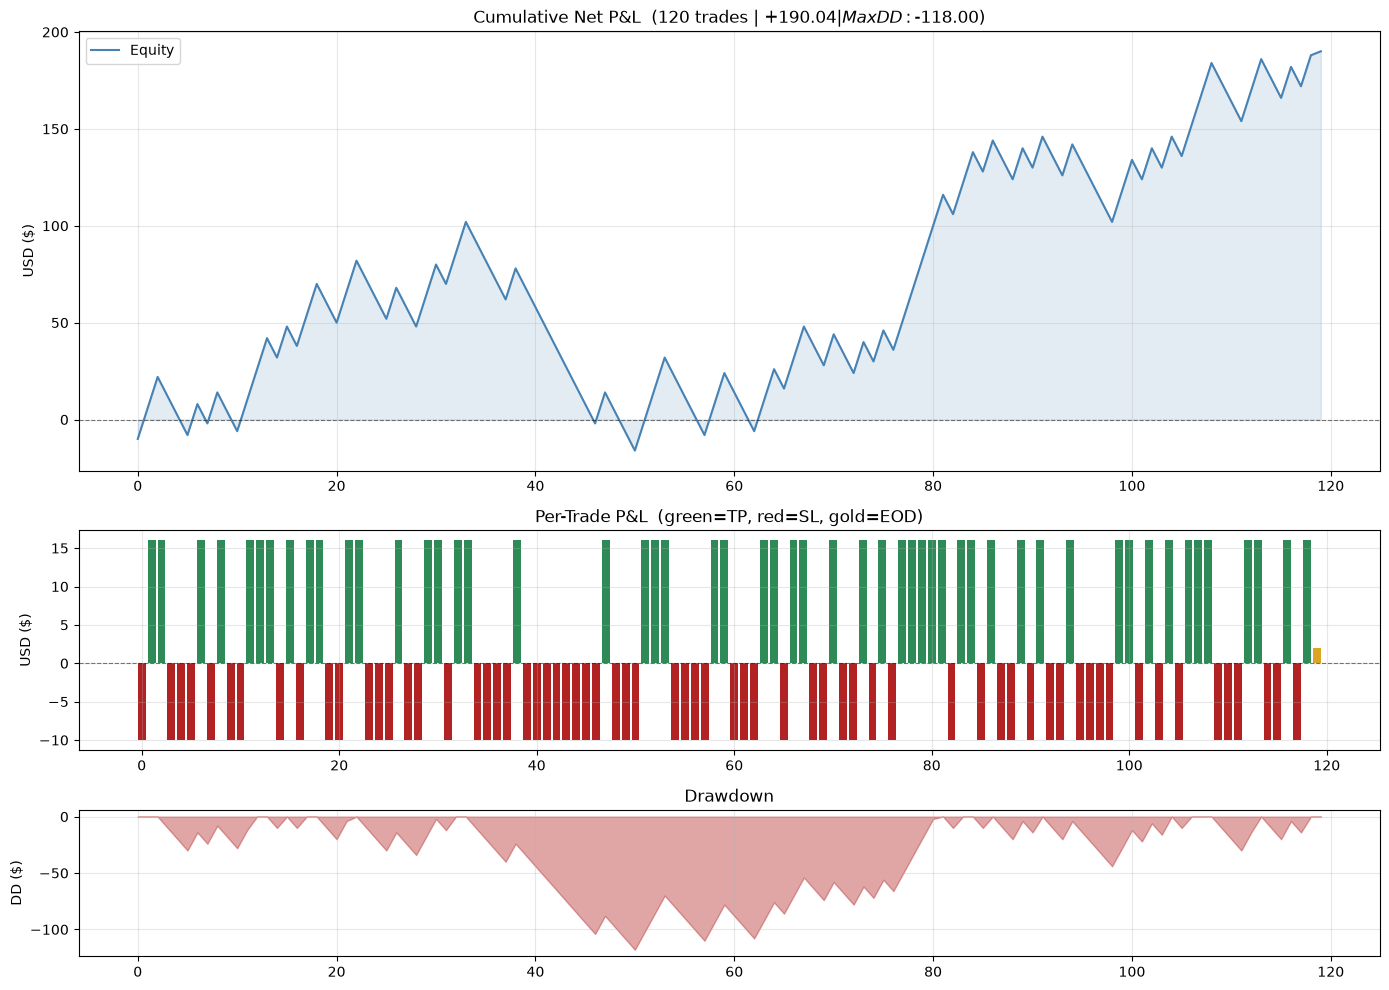

In [128]:
if len(trades) == 0:
    print("No trades to display.")
else:
    def _summary_stats(df):
        if len(df) == 0:
            return {}
        wins = (df['outcome'] == 'tp').sum()
        losses = (df['outcome'] == 'sl').sum()
        total_closed = wins + losses
        win_rate = (wins / total_closed * 100) if total_closed > 0 else 0.0
        return {
            'Trades':          len(df),
            'Wins (TP)':       wins,
            'Losses (SL)':     losses,
            'EOD Close':       (df['outcome'] == 'eod').sum(),
            'Win Rate %':      round(win_rate, 1),
            'Net USD ($)':     round(df['net_usd'].sum(), 2),
            'Avg USD ($)':     round(df['net_usd'].mean(), 2),
            'Best Trade ($)':  round(df['net_usd'].max(), 2),
            'Worst Trade ($)': round(df['net_usd'].min(), 2),
            'Commission ($)':  round(df['commission'].sum(), 2),
        }

    stats = pd.DataFrame({
        'ALL':  _summary_stats(trades),
        'BUY':  _summary_stats(trades[trades['direction'] == 'BUY']),
        'SELL': _summary_stats(trades[trades['direction'] == 'SELL']),
    }).T
    display(stats)

    trades_sorted = trades.rename(columns={'signal_time': 'time'}).sort_values('time').reset_index(drop=True)
    trades_sorted['cum_usd'] = trades_sorted['net_usd'].cumsum()
    running_max = trades_sorted['cum_usd'].cummax()
    drawdown    = trades_sorted['cum_usd'] - running_max
    max_dd      = drawdown.min()

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1.5, 1]})

    axes[0].plot(trades_sorted.index, trades_sorted['cum_usd'], color='steelblue', lw=1.5, label='Equity')
    axes[0].fill_between(trades_sorted.index, trades_sorted['cum_usd'], alpha=0.15, color='steelblue')
    axes[0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    axes[0].set_title(
        f'Cumulative Net P&L  ({len(trades):,} trades | ${trades_sorted["cum_usd"].iloc[-1]:+,.2f} | MaxDD: ${max_dd:.2f})')
    axes[0].set_ylabel('USD ($)'); axes[0].grid(alpha=0.3); axes[0].legend()

    colours = trades_sorted['outcome'].map({'tp': 'seagreen', 'sl': 'firebrick', 'eod': 'goldenrod'})
    axes[1].bar(trades_sorted.index, trades_sorted['net_usd'], color=colours, width=0.8)
    axes[1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    axes[1].set_ylabel('USD ($)')
    axes[1].set_title('Per-Trade P&L  (green=TP, red=SL, gold=EOD)')
    axes[1].grid(alpha=0.3)

    axes[2].fill_between(trades_sorted.index, drawdown, 0, color='firebrick', alpha=0.4)
    axes[2].set_ylabel('DD ($)'); axes[2].set_title('Drawdown'); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Threshold Sweep

In [129]:
signal_thresholds = [0.99, 0.95, 0.90, 0.80, 0.70]
quality_thresholds = [0.00, 0.25, 0.50, 0.60, 0.70]

results = []
for quality_threshold in quality_thresholds:
    for signal_threshold in signal_thresholds:
        trial_frame = df_raw.merge(pred_df, on='Time', how='inner').sort_values('Time').reset_index(drop=True)
        trial_signal_cols = trial_frame.apply(
            prediction_to_signal,
            axis=1,
            trade_threshold=signal_threshold,
            quality_threshold=quality_threshold,
            trading_hours=TRADING_HOURS,
        )
        trial_frame = pd.concat([trial_frame, trial_signal_cols], axis=1)
        trial_frame['signal'] = trial_frame['raw_signal'].astype(int)

        trial_sim, trial_trades = simulate_production_trades(
            trial_frame,
            atr_window=atr_window,
            tp_mult=tp_mult,
            sl_mult=sl_mult,
            patience=PATIENCE,
            entry_buffer=ENTRY_BUFFER,
            trading_hours=TRADING_HOURS,
            risk_per_trade=RISK,
            commission_per_lot=COMMISSION_USD,
            max_pos_size=MAX_POS_SIZE,
        )

        trial_net = float(trial_trades['net_usd'].sum()) if len(trial_trades) else 0.0
        trial_win = float((trial_trades['outcome'] == 'tp').mean() * 100) if len(trial_trades) else 0.0
        trial_avg = float(trial_trades['net_usd'].mean()) if len(trial_trades) else 0.0
        results.append({
            'trade_threshold': signal_threshold,
            'quality_threshold': quality_threshold,
            'trades': int(len(trial_trades)),
            'win_rate_pct': round(trial_win, 1),
            'avg_net_usd': round(trial_avg, 2),
            'net_usd': round(trial_net, 2),
        })

results_df = pd.DataFrame(results).sort_values(['net_usd', 'win_rate_pct', 'trades'], ascending=[False, False, False]).reset_index(drop=True)
display(results_df.head(20))


,trade_threshold,quality_threshold,trades,win_rate_pct,avg_net_usd,net_usd
0,0.80,0.25,268,41.4,0.81,218.04
1,0.80,0.00,267,41.2,0.76,202.04
2,0.70,0.60,139,43.9,1.41,196.00
3,0.80,0.60,120,44.2,1.58,190.04
4,0.90,0.50,93,44.1,1.46,136.00
5,0.90,0.00,113,42.5,1.04,118.00
6,0.70,0.70,38,50.0,3.00,114.00
7,0.90,0.25,111,42.3,1.01,112.00
8,0.80,0.70,36,50.0,3.00,108.00
9,0.95,0.00,33,45.5,1.82,60.00


In [130]:
MIN_TRADES_FOR_RECOMMENDATION = max(25, int(len(df_gated) * 0.003))

eligible = results_df[results_df['trades'] >= MIN_TRADES_FOR_RECOMMENDATION].copy()
if eligible.empty:
    eligible = results_df.copy()

recommended = eligible.sort_values(
    ['net_usd', 'win_rate_pct', 'trades'],
    ascending=[False, False, False],
).iloc[0]

print('Recommended production thresholds')
print(f"  trade_threshold : {recommended['trade_threshold']:.2f}")
print(f"  quality_threshold: {recommended['quality_threshold']:.2f}")
print(f"  expected trades  : {int(recommended['trades'])}")
print(f"  win rate         : {recommended['win_rate_pct']:.1f}%")
print(f"  net USD          : ${recommended['net_usd']:.2f}")
print(f"  avg net/trade    : ${recommended['avg_net_usd']:.2f}")
print(f"  min trades rule  : {MIN_TRADES_FOR_RECOMMENDATION}")

print('\nTop 10 threshold candidates')
display(eligible.head(10))


Recommended production thresholds
  trade_threshold : 0.80
  quality_threshold: 0.25
  expected trades  : 268
  win rate         : 41.4%
  net USD          : $218.04
  avg net/trade    : $0.81
  min trades rule  : 29

Top 10 threshold candidates


,trade_threshold,quality_threshold,trades,win_rate_pct,avg_net_usd,net_usd
0,0.80,0.25,268,41.4,0.81,218.04
1,0.80,0.00,267,41.2,0.76,202.04
2,0.70,0.60,139,43.9,1.41,196.00
3,0.80,0.60,120,44.2,1.58,190.04
4,0.90,0.50,93,44.1,1.46,136.00
5,0.90,0.00,113,42.5,1.04,118.00
6,0.70,0.70,38,50.0,3.00,114.00
7,0.90,0.25,111,42.3,1.01,112.00
8,0.80,0.70,36,50.0,3.00,108.00
9,0.95,0.00,33,45.5,1.82,60.00


## Build Forward Outcome and Directional PnL
Uses fixed-horizon future close movement to derive realized signed outcome and trade PnL.

In [131]:
# close_map = df_raw[['Time', 'Close']].copy()
# close_map['Time'] = pd.to_datetime(close_map['Time'])
# eval_df = pred_df.merge(close_map, on='Time', how='left').rename(columns={'Close': 'close_t'})

# time_to_pos = {t: i for i, t in enumerate(close_map['Time'])}
# close_vals = close_map['Close'].to_numpy()

# fwd_close = np.full(len(eval_df), np.nan, dtype=float)
# for i, t in enumerate(eval_df['Time']):
#     pos = time_to_pos.get(t, None)
#     if pos is None:
#         continue
#     pos_fwd = pos + LOOKAHEAD_BARS
#     if pos_fwd < len(close_vals):
#         fwd_close[i] = close_vals[pos_fwd]

# eval_df['close_fwd'] = fwd_close
# eval_df = eval_df.dropna(subset=['close_t', 'close_fwd']).reset_index(drop=True)

# eval_df['true_signed_move'] = eval_df['close_fwd'] - eval_df['close_t']
# eval_df['position'] = np.sign(eval_df['pred_signed'])
# eval_df['raw_pnl_pips'] = eval_df['position'] * (eval_df['true_signed_move'] / PIP_SIZE)
# eval_df['raw_pnl_usd'] = eval_df['raw_pnl_pips'] * (PIP_VALUE_USD * LOT_SIZE)
# eval_df['net_pnl_usd'] = eval_df['raw_pnl_usd'] - COMMISSION_USD
# eval_df['is_hit'] = (np.sign(eval_df['pred_signed']) == np.sign(eval_df['true_signed_move'])).astype(int)

# print('Backtest rows:', len(eval_df))
# print('Mean net PnL per trade: %.4f USD' % eval_df['net_pnl_usd'].mean())
# eval_df[['Time', 'pred_signed', 'true_signed_move', 'net_pnl_usd']].head()

## Top-Bucket Lift Backtest (1%, 5%, 10%)
Evaluates directional lift by selecting the strongest absolute predictions.

In [132]:
# def topk_lift_backtest(df, pred_col='pred_signed', top_pcts=(0.01, 0.05, 0.10)):
#     out_rows = []

#     base_mean_pnl = float(df['net_pnl_usd'].mean())
#     base_hit = float(df['is_hit'].mean())

#     for p in top_pcts:
#         p = float(p)
#         threshold = np.quantile(np.abs(df[pred_col]), 1.0 - p)
#         sel = np.abs(df[pred_col]) >= threshold
#         n = int(sel.sum())
#         if n == 0:
#             continue

#         d = df.loc[sel]
#         mean_pnl = float(d['net_pnl_usd'].mean())
#         hit = float(d['is_hit'].mean())

#         out_rows.append({
#             'top_pct': f'{int(p*100)}%',
#             'n_trades': n,
#             'coverage': n / len(df),
#             'baseline_mean_pnl': base_mean_pnl,
#             'top_mean_pnl': mean_pnl,
#             'pnl_lift': np.nan if abs(base_mean_pnl) < 1e-12 else mean_pnl / base_mean_pnl,
#             'baseline_hit_rate': base_hit,
#             'top_hit_rate': hit,
#             'hit_lift': np.nan if abs(base_hit) < 1e-12 else hit / base_hit,
#             'total_net_pnl_usd': float(d['net_pnl_usd'].sum()),
#         })

#     return pd.DataFrame(out_rows)

# lift_df = topk_lift_backtest(eval_df, pred_col='pred_signed', top_pcts=TOP_PCTS)
# display(lift_df.round(4))

In [133]:
# # Equity curve for all directional trades and top 1% bucket
# fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

# all_curve = eval_df.sort_values('Time').reset_index(drop=True)
# all_curve['equity_usd'] = all_curve['net_pnl_usd'].cumsum()
# axes[0].plot(all_curve.index, all_curve['equity_usd'], color='steelblue', lw=1.4)
# axes[0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
# axes[0].set_title('Equity Curve - All Signals')
# axes[0].set_ylabel('USD')
# axes[0].grid(alpha=0.3)

# p_top = min(TOP_PCTS)
# thr = np.quantile(np.abs(eval_df['pred_signed']), 1.0 - p_top)
# top_df = eval_df.loc[np.abs(eval_df['pred_signed']) >= thr].sort_values('Time').reset_index(drop=True)
# top_df['equity_usd'] = top_df['net_pnl_usd'].cumsum()
# axes[1].plot(top_df.index, top_df['equity_usd'], color='darkorange', lw=1.4)
# axes[1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
# axes[1].set_title(f'Equity Curve - Top {int(p_top*100)}% |pred_signed|')
# axes[1].set_xlabel('Trade index')
# axes[1].set_ylabel('USD')
# axes[1].grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

## Optional Export
Exports aligned predictions and backtest outcomes for external analysis.

In [134]:
# export_name = os.path.splitext(os.path.basename(MODEL_PACK_PATH))[0]
# pred_path = f'../ModelWorkbench/{export_name}_predictions.csv'
# bt_path = f'../ModelWorkbench/{export_name}_backtest.csv'

# pred_df.to_csv(pred_path, index=False)
# eval_df.to_csv(bt_path, index=False)

# print('Saved predictions:', pred_path)
# print('Saved backtest:', bt_path)